In [15]:
# NYC Regents Performance Analysis
### Comparing P.S. 184m Shuang Wen to All Schools (Common Core Algebra, 2015–2017)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
url = "https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv"
df = pd.read_csv(url)


In [5]:
shuang_wen = df[df["School Name"].str.contains("Shuang Wen", na=False)]
print(shuang_wen.shape)

(49, 15)


In [6]:
shuang_wen = df[df["School DBN"] == "01M184"]
print(shuang_wen.columns.tolist())

['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year', 'Total Tested', 'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65', 'Number Scoring 65 or Above', 'Percent Scoring 65 or Above', 'Number Scoring 80 or Above', 'Percent Scoring 80 or Above', 'Number Scoring CR', 'Percent Scoring CR']


In [7]:
shuang_wen = df[df["School Name"] == "P.S. 184m Shuang Wen"]

In [8]:
print(shuang_wen.loc[shuang_wen["Mean Score"].idxmax(), ["Year", "Regents Exam", "Mean Score"]])
print(shuang_wen.loc[shuang_wen["Mean Score"].idxmin(), ["Year", "Regents Exam", "Mean Score"]])

Year                           2015
Regents Exam    Common Core Algebra
Mean Score                        s
Name: 19489, dtype: object
Year                           2016
Regents Exam    Common Core Algebra
Mean Score                       77
Name: 102897, dtype: object


In [12]:
df["Mean Score"] = pd.to_numeric(df["Mean Score"], errors="coerce")
df["Total Tested"] = pd.to_numeric(df["Total Tested"], errors="coerce")

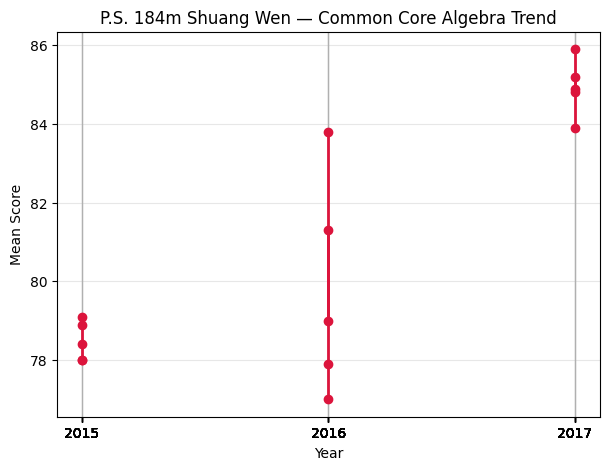

In [13]:
shuang_wen = df[(df["School Name"] == "P.S. 184m Shuang Wen") &
                (df["Regents Exam"] == "Common Core Algebra")].sort_values("Year")

plt.figure(figsize=(7, 5))
plt.plot(shuang_wen["Year"], shuang_wen["Mean Score"],
         marker="o", color="crimson", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Mean Score")
plt.title("P.S. 184m Shuang Wen — Common Core Algebra Trend")
plt.xticks(shuang_wen["Year"])
plt.grid(alpha=0.3)
plt.show()

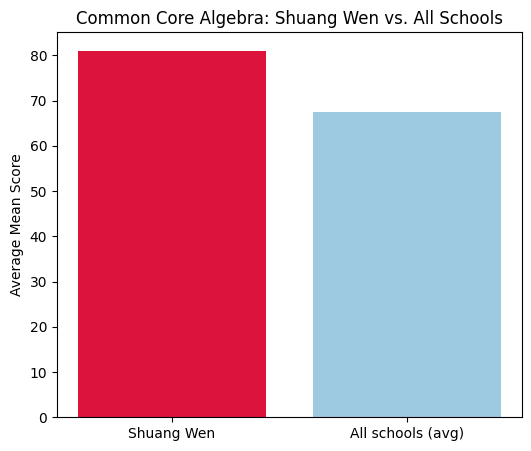

In [14]:
comparison_group = df[df["Regents Exam"] == "Common Core Algebra"]
shuang_wen = df[(df["School Name"] == "P.S. 184m Shuang Wen") &
                (df["Regents Exam"] == "Common Core Algebra")]

labels = ["Shuang Wen", "All schools (avg)"]
values = [shuang_wen["Mean Score"].mean(), comparison_group["Mean Score"].mean()]

plt.figure(figsize=(6, 5))
plt.bar(labels, values, color=["crimson", "#9ecae1"])
plt.ylabel("Average Mean Score")
plt.title("Common Core Algebra: Shuang Wen vs. All Schools")
plt.show()

Across the recorded time period, the P.S. 184 Shuang Wen school had an edge compared to the comparison
group on the Common Core Algebra Regents. Its scores also
trend upward over time, suggesting improving performance.
This is based on a small sample, so results should be checked
against the full NYC dataset before drawing citywide conclusions.